In [3]:
import numpy as np
import matplotlib.pyplot as plt
import bordado as bd

from tremelique._utils import homogeneous_model_xarray, model
from tremelique._acoustic import Acoustic
from tremelique._wavelets import RickerWavelet

region = [0, 2000, 0, 1500]
spacing = 5
props = {"velocity":1500, "density":1000}

model = model(region, spacing, properties=props)


In [5]:
sim = Acoustic(model=model, dt=0.001)
sim.add_point_source((0, 200),RickerWavelet(1,60))
sim.run(400)

Output()

C:\Users\paulo\miniforge3\envs\tremelique\Lib\site-packages\numba\core\typed_passes.py:336: 
NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see 
https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "..\tremelique\_acoustic.py", line 533:
@numba.jit(nopython=True, parallel=True)
def timestep_esg(u_tp1, u_t, u_tm1, x1, x2, z1, z2, dt, dx, dz, vel, dens):
^

  warnings.warn(errors.NumbaPerformanceWarning(msg,

In [6]:
sim.snapshot(20, embed=True)
anim = sim.animate(every=10, embed=True, cutoff=0.5)
anim

In [7]:
model.z.attrs["units"] = "m"
model.z.attrs["long_name"] = "vertical"
model.density.attrs["units"] = "kg/m³"

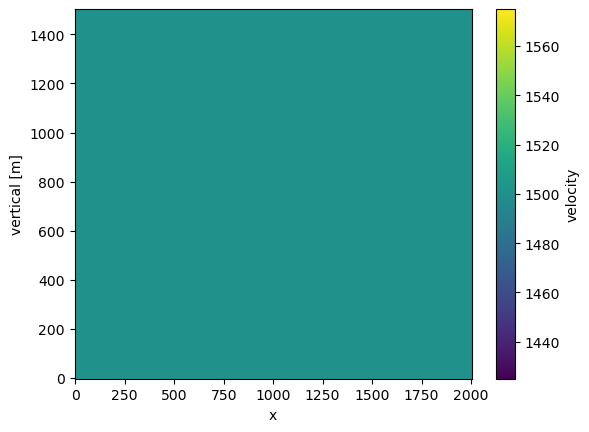

In [8]:
model.velocity.plot()

**Quero**

`sim.wavefield.sel(time=slice(0, 2), x=1000, z=0)`

**Quero está funcionando**

`sim.wavefield.sel(time=slice(0, 2), x=1000, z=0)`

In [9]:
sim.wavefield.sel(time=slice(0, 2), x=1000, z=0)

<xarray.Dataset> Size: 5kB
Dimensions:   (time: 400)
Coordinates:
  * time      (time) float64 3kB 0.0 0.001 0.002 0.003 ... 0.397 0.398 0.399
    z         float32 4B 0.0
    x         float32 4B 1e+03
Data variables:
    panels    (time) float32 2kB ...
    velocity  float32 4B ...
    density   float32 4B ...
    sources   <U136 544B ...
Attributes:
    dx:         5
    dz:         5
    dt:         0.001
    padding:    50
    taper:      0.005
    shape:      [301 401]
    simsize:    400
    iteration:  399

In [ ]:
plt.imshow(sim[:, 0, :])
plt.show()

In [ ]:
model[zname][1] - model[zname][0]